In [1]:
import cv2
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from mpmath.visualization import blue_orange_colors

In [2]:
img_path = "/Users/akhildevarashetti/code/vision_lab/vision_lab/adhoc/car.png"

In [3]:
# Read the PNG image with the 'cv2.IMREAD_UNCHANGED' flag to preserve transparency
img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
img.shape

(878, 2013, 4)

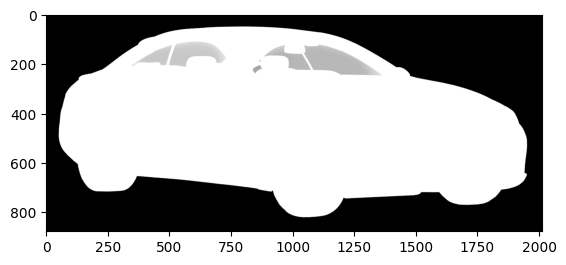

In [4]:
plt.imshow(img[:, :, 3], cmap="gray")

In [5]:
unique, counts = np.unique(img[:,:,3], return_counts=True)
np.asarray((unique, counts)).T

array([[     0, 722286],
       [     1,    216],
       [     2,    140],
       [     3,    123],
       [     4,     94],
       [     5,     93],
       [     6,    105],
       [     7,     67],
       [     8,     76],
       [     9,     66],
       [    10,     81],
       [    11,     68],
       [    12,     59],
       [    13,     52],
       [    14,     69],
       [    15,     54],
       [    16,     39],
       [    17,     44],
       [    18,     33],
       [    19,     40],
       [    20,     43],
       [    21,     53],
       [    22,     25],
       [    23,     54],
       [    24,     32],
       [    25,     26],
       [    26,     36],
       [    27,     53],
       [    28,     36],
       [    29,     36],
       [    30,     32],
       [    31,     35],
       [    32,     44],
       [    33,     31],
       [    34,     39],
       [    35,     19],
       [    36,     40],
       [    37,     36],
       [    38,     34],
       [    39,     31],


In [6]:
# d = int(np.sqrt(h ** 2 + w ** 2))
d = int((img[:, :, 3].max(axis=0) / 255).sum())  # width of the car itself (ignoring the mask)
d

1900

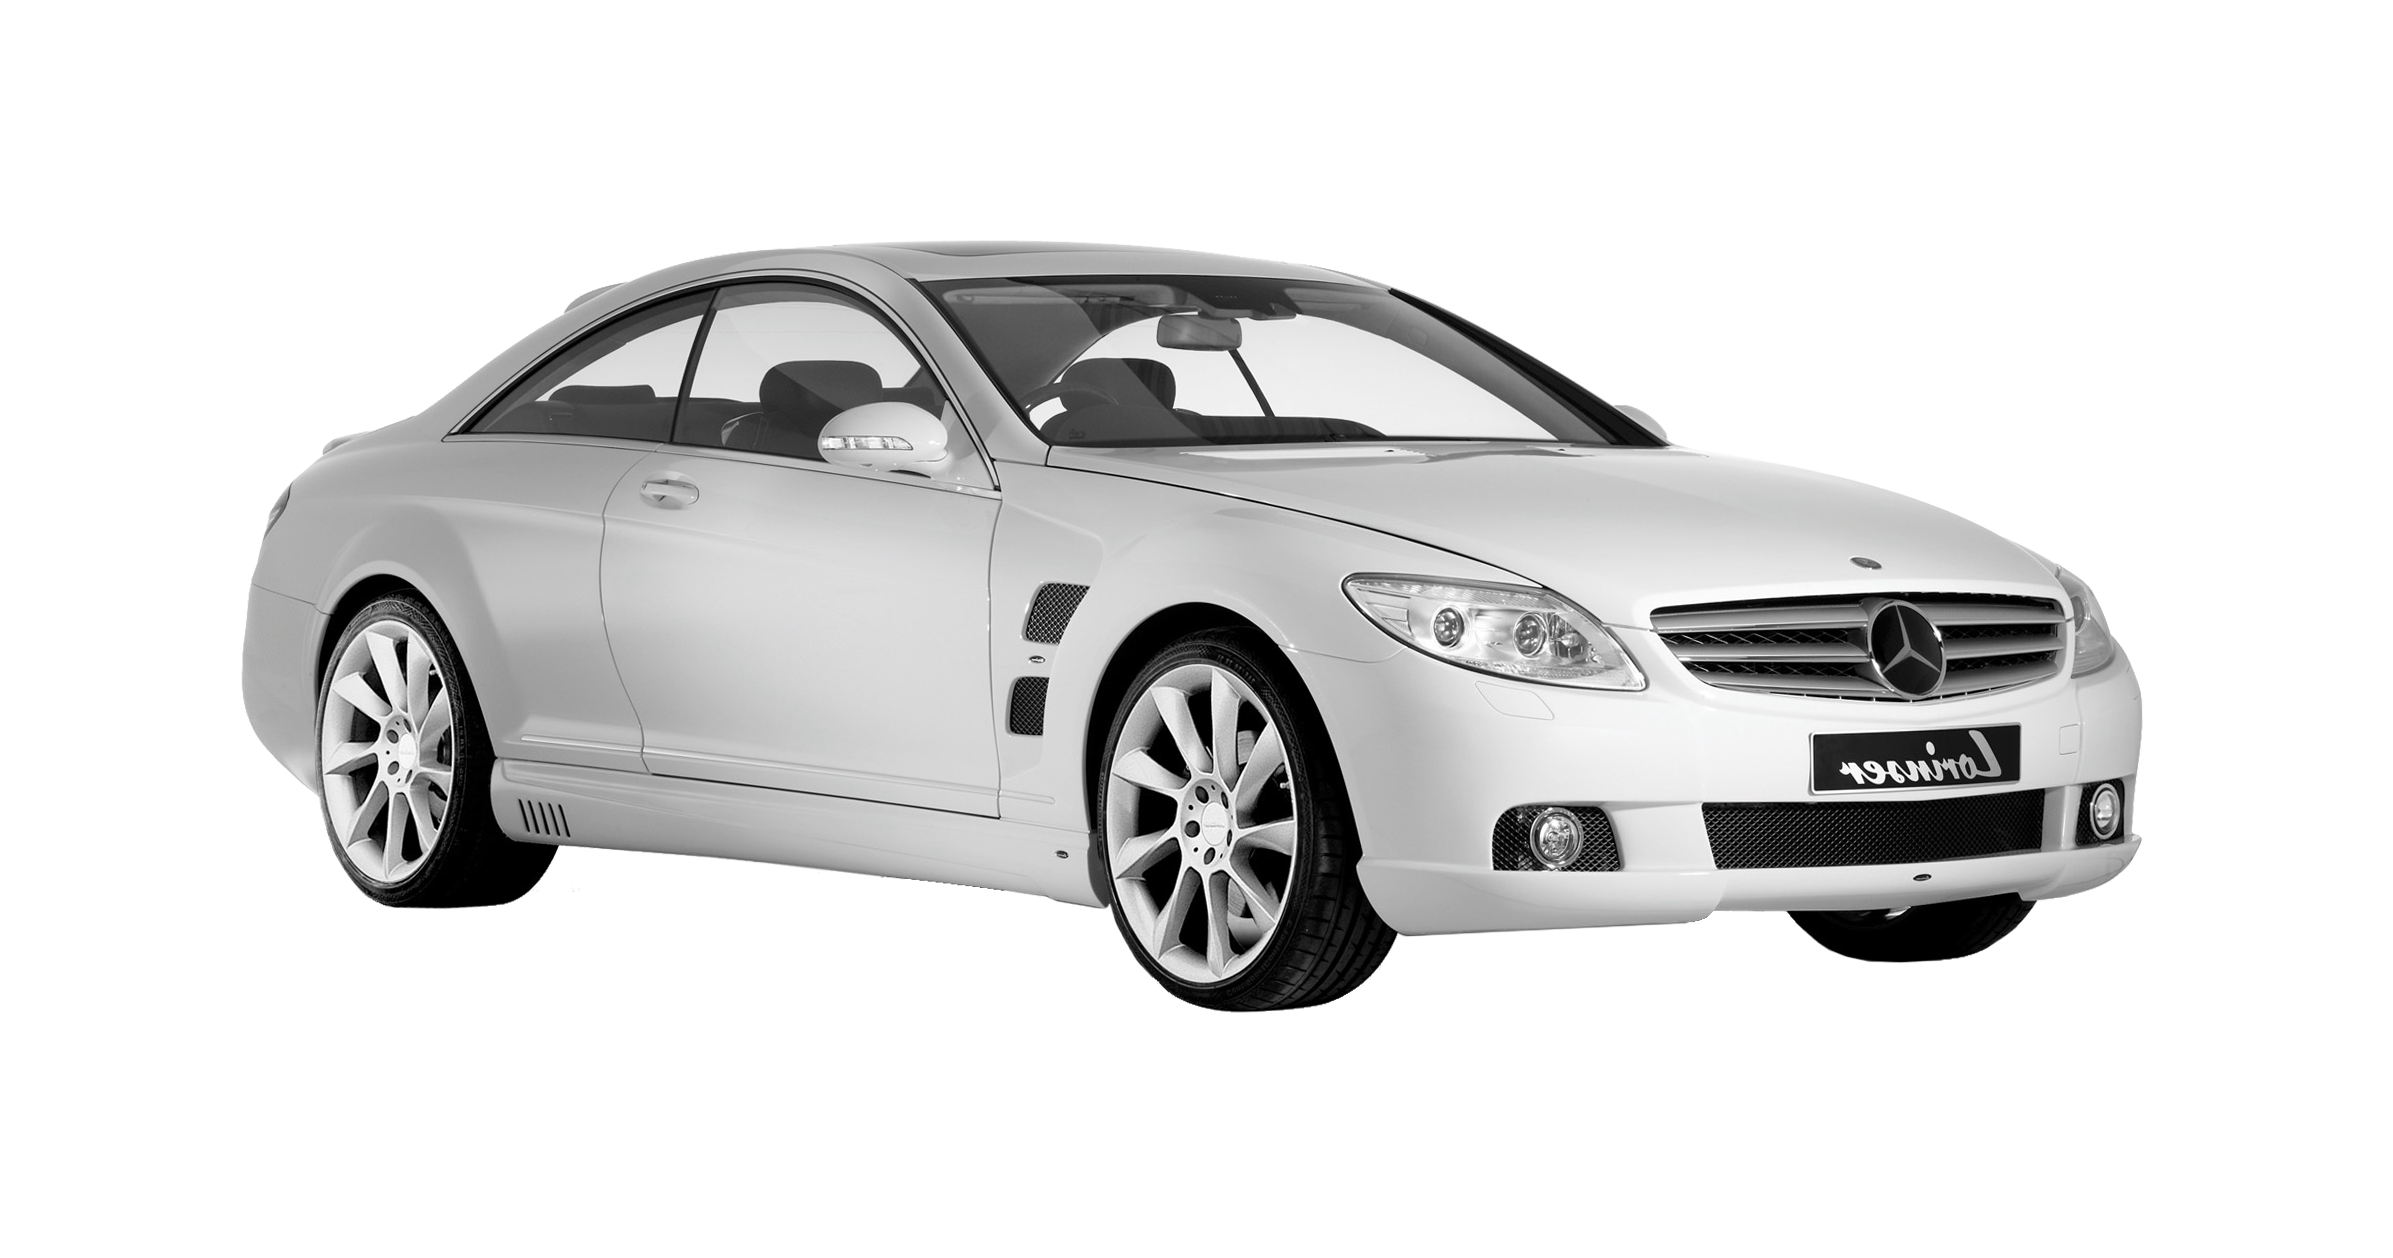

In [7]:
# Add white borders.
pad = int(d * 0.1)
img = np.pad(img, ((pad, pad), (pad, pad), (0, 0)))
h, w, _ = img.shape
Image.fromarray(img)

(1258, 2393) (1258, 2393, 4)


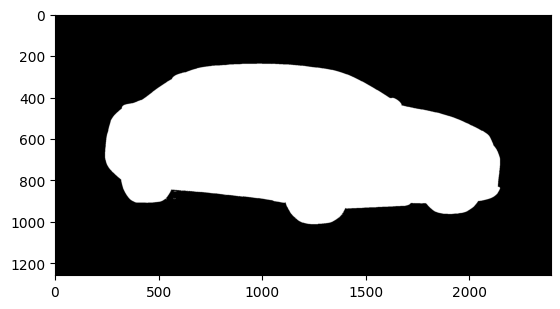

In [8]:
mask = img[:, :, 3] != 0
print(mask.shape, img.shape)
plt.imshow(mask, cmap="gray")

0 is background. Exact 255 is car present. Anything in between is a translucent area like windows.

In [9]:
offset = int(d * 0.07)

shadow_d = np.ones(mask.shape)

shadow_d[offset:] = 1 - mask[:h-offset]

shadow_d *= 255

shadow_d = shadow_d.astype(np.uint8)

blur_window = int(d * 0.15)
blur_window = (blur_window // 2) * 2 + 1
blur_window = (blur_window, blur_window)
shadow_d_blur = cv2.GaussianBlur(shadow_d, blur_window, 0)
shadow_d_rgb = np.expand_dims(shadow_d_blur, 2)
shadow_d_rgb = np.repeat(shadow_d_rgb, 3, 2)

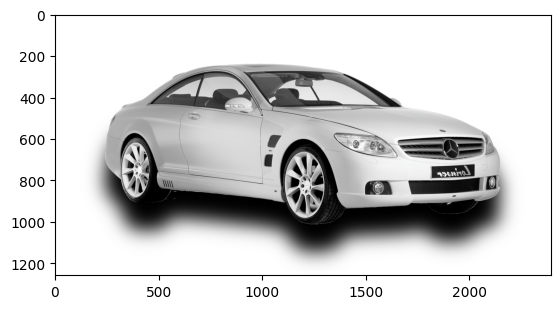

In [10]:
# Overlap shadow and image
mask_3_channel = np.stack([mask, mask, mask], axis=2)
image_with_shadow = img[:, :, :3] * mask_3_channel + shadow_d_rgb * (1 - mask_3_channel)
plt.imshow(image_with_shadow)

In [11]:
shadow_l = np.ones(mask.shape)

shadow_l[:, offset:] = 1 - mask[:, :w-offset]

shadow_l *= 255

shadow_l = shadow_l.astype(np.uint8)

shadow_l_blur = cv2.GaussianBlur(shadow_l, blur_window, 0)
shadow_l_rgb = np.stack([shadow_l_blur, shadow_l_blur, shadow_l_blur], axis=2)

In [12]:
shadow_r = np.ones(mask.shape)

shadow_r[:, :w-offset] = 1 - mask[:, offset:]

shadow_r *= 255

shadow_r = shadow_r.astype(np.uint8)

shadow_r_blur = cv2.GaussianBlur(shadow_r, blur_window, 0)
shadow_r_rgb = np.stack([shadow_r_blur, shadow_r_blur, shadow_r_blur], axis=2)

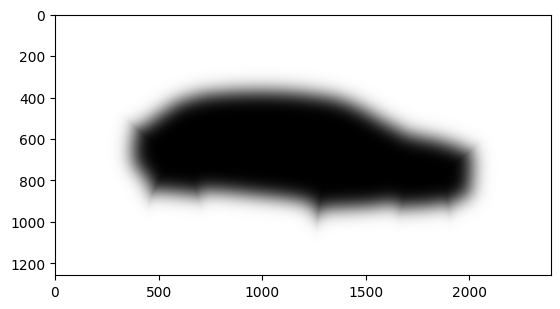

In [13]:
shadow_min = np.max([shadow_d_rgb, shadow_l_rgb, shadow_r_rgb], axis=0).astype(np.uint8)
plt.imshow(shadow_min)

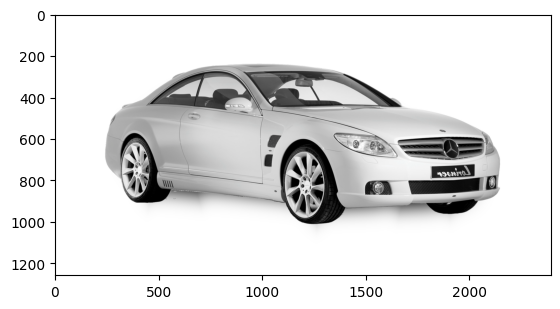

In [14]:
image_with_shadow = img[:, :, :3] * mask_3_channel + shadow_min * (1 - mask_3_channel)
plt.imshow(image_with_shadow)

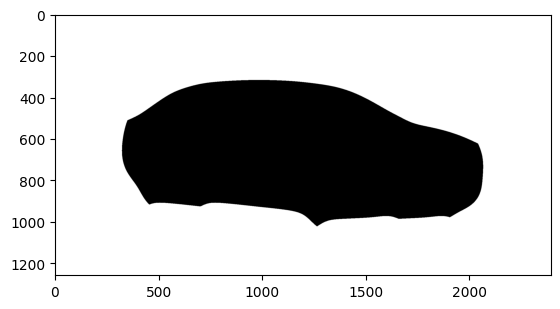

In [15]:
threshold = 0.9

shadow_max_hard = ((1 - (shadow_min < 255 * threshold)) * 255).astype(np.uint8)
plt.imshow(shadow_max_hard)

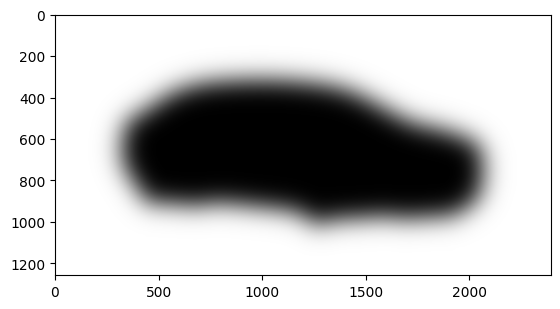

In [16]:
post_blur = int(d * 0.2)
post_blur = (post_blur // 2) * 2 + 1
# shadow_max_blur = cv2.GaussianBlur(shadow_min, (post_blur, post_blur), 0)
shadow_max_blur = cv2.GaussianBlur(shadow_max_hard, (post_blur, post_blur), 0)
plt.imshow(shadow_max_blur)

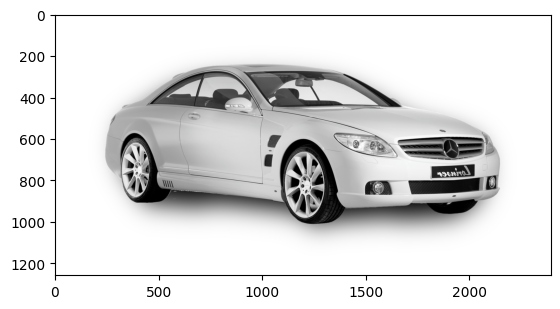

In [17]:
image_with_shadow = img[:, :, :3] * mask_3_channel + shadow_max_blur * (1 - mask_3_channel)
plt.imshow(image_with_shadow)

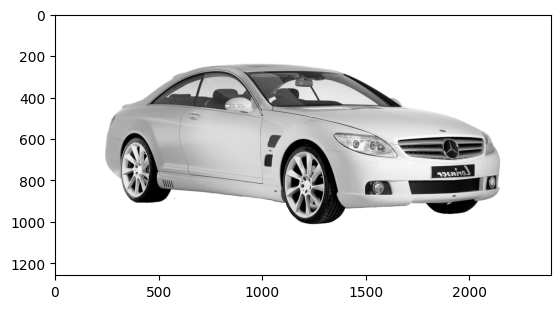

In [18]:
plt.imshow(img[:, :, :3] * mask_3_channel + ((1 - mask_3_channel) * 255).astype(np.uint8))

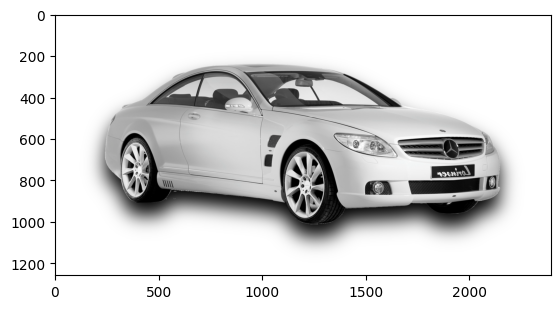

In [19]:
offset = int(h * 0.05)
shadow_d = np.ones(mask.shape)

shadow_d[offset:] = 1 - mask[:h-offset]

shadow_d *= 255

shadow_d = shadow_d.astype(np.uint8)

shadow_d_blur = cv2.GaussianBlur(shadow_d, blur_window, 0)

shadow_d_rgb = np.expand_dims(shadow_d_blur, 2)
shadow_d_rgb = np.repeat(shadow_d_rgb, 3, 2)

# opacity = 0.5
# shadow_d_rgb = (shadow_d_rgb / opacity).clip(0, 255).astype(np.uint8)

image_with_shadow = img[:, :, :3] * mask_3_channel + shadow_d_rgb * (1 - mask_3_channel)
plt.imshow(image_with_shadow)